In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import WeightedRandomSampler
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt
from Model.MENDR.MENDR import MENDR_model
#from Model.MENDR.MENDREncoder import MENDRPatchEncoder
from Model.MENDR.mAtt.optimizer import MixOptimizer
from Model.MENDR.mAtt.spd import SPDTangentSpace
import random
import os
import math
from Datasets.datasetTUEV import WaveletTUEVDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc, f1_score, cohen_kappa_score
from torchjd import mtl_backward
from torchjd.aggregation import UPGrad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
seed = 126
### Seed ###
torch.cuda.empty_cache()
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [5]:
print("*" * 50)
finetune_train_dataset = WaveletTUEVDataset(root="/home/hice1/mchen439/scratch/TUEV/train", frac=1.0, split="train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_test_dataset = WaveletTUEVDataset(root="/home/hice1/mchen439/scratch/TUEV/eval", frac=1.0, split="eval")
print("Dataset Loaded. Length of Test Dataset: ", len(finetune_test_dataset))

**************************************************
Indexing 83932 folders


100%|██████████| 83932/83932 [02:09<00:00, 649.35it/s]


Dataset Loaded. Length of Train Dataset:  83932
Indexing 29421 folders


100%|██████████| 29421/29421 [00:45<00:00, 647.00it/s]

Dataset Loaded. Length of Test Dataset:  29421


In [5]:
#finetune_train_dataset, finetune_val_dataset = torchdata.random_split(finetune_train_dataset, [0.8, 0.2])
#print(len(finetune_train_dataset), len(finetune_val_dataset))

In [6]:
print(finetune_train_dataset[0]['graph'])
print(finetune_train_dataset[0]['delta'].shape)
print(finetune_train_dataset[0]['theta'].shape)
print(finetune_train_dataset[0]['alpha'].shape)
print(finetune_train_dataset[0]['beta'].shape)
print(finetune_train_dataset[0]['gamma'].shape)
print(finetune_train_dataset[0]['graph'].y)
print(finetune_train_dataset[1]['graph'].y)
print(finetune_train_dataset[2]['graph'].y)
print(finetune_train_dataset[3]['graph'].y)
print(finetune_train_dataset[4]['graph'].y)
print(finetune_train_dataset[5]['graph'].y)
print(finetune_train_dataset[6]['graph'].y)
print(finetune_train_dataset[7]['graph'].y)
print(finetune_train_dataset[8]['graph'].y)
print(finetune_train_dataset[9]['graph'].y)
print(finetune_test_dataset[0]['graph'].y)
print(finetune_test_dataset[29000]['graph'].y)
print(finetune_test_dataset[29010]['graph'].y)
print(finetune_test_dataset[29020]['graph'].y)
print(finetune_test_dataset[29030]['graph'].y)

Data(edge_index=[2, 361], edge_attr=[361, 1], pos=[19, 3], y=[1])
torch.Size([19, 24])
torch.Size([19, 24])
torch.Size([19, 48])
torch.Size([19, 96])
torch.Size([19, 192])
tensor([5])
tensor([5])
tensor([5])
tensor([5])
tensor([5])
tensor([5])
tensor([2])
tensor([1])
tensor([4])
tensor([5])
tensor([5])
tensor([5])
tensor([2])
tensor([5])
tensor([3])


In [8]:
train_label_count = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0
}
y_train = []
for i in tqdm.tqdm(range(len(finetune_train_dataset))):
    graph = finetune_train_dataset[i]['graph']
    train_label = graph.y.item()
    assert train_label >= 0 and train_label <= 5, f"Label {train_label} is not in range [0, 5]"
    train_label_count[train_label] += 1
    y_train.append(train_label)

print(train_label_count)

  9%|▉         | 7562/83932 [11:12<1:53:12, 11.24it/s]


KeyboardInterrupt: 

In [8]:
test_label_count = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0
}

y_test = []
for i in range(len(finetune_test_dataset)):
    graph = finetune_test_dataset[i]['graph']
    test_label = graph.y.item()
    assert test_label >= 0 and test_label <= 5, f"{test_label} is not a valid label"
    test_label_count[test_label] += 1
    y_test.append(test_label)

print(test_label_count)

{0: 567, 1: 4677, 2: 1998, 3: 329, 4: 2204, 5: 19646}


In [9]:
train_label_counts_arr = np.array(list(train_label_count.values()))
train_sampler_class_weight = 1. / torch.from_numpy(train_label_counts_arr)
train_samples_weight = np.array([train_sampler_class_weight[t] for t in y_train])
train_sampler = WeightedRandomSampler(weights=train_samples_weight, num_samples=len(train_samples_weight))

test_label_counts_arr = np.array(list(test_label_count.values()))
test_sampler_class_weight = 1. / torch.from_numpy(test_label_counts_arr)
test_samples_weight = np.array([test_sampler_class_weight[t] for t in y_test])
test_sampler = WeightedRandomSampler(weights=test_samples_weight, num_samples=len(test_samples_weight))

print(train_sampler_class_weight)
print(test_sampler_class_weight)
print(train_samples_weight.shape)
print(test_samples_weight.shape)

tensor([1.5504e-03, 8.8857e-05, 1.6171e-04, 9.3458e-04, 9.0473e-05, 1.8613e-05])
tensor([1.7637e-03, 2.1381e-04, 5.0050e-04, 3.0395e-03, 4.5372e-04, 5.0901e-05])
(83932,)
(29421,)


In [8]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=128, num_workers=32, pin_memory=True, persistent_workers=True, shuffle=True)
#finetune_val_loader = DataLoader(finetune_val_dataset, batch_size=64, num_workers=16, pin_memory=True, persistent_workers=True, shuffle=False)
finetune_test_loader = DataLoader(finetune_test_dataset, batch_size=128, num_workers=32, pin_memory=True, persistent_workers=True, shuffle=False)
print(len(finetune_train_loader), len(finetune_test_loader))
#print(len(finetune_train_loader), len(finetune_val_loader), len(finetune_test_loader))
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

656 230


/home/hice1/mchen439/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 16, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
class LayerNormChannelOnly(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.layer_norm = nn.LayerNorm(num_channels)

    def forward(self, x):
        # Expects x [Batch Size, Channels, Time Steps]
        x = x.permute(0, 2, 1)
        x = self.layer_norm(x)
        return x.permute(0, 2, 1)

In [10]:
class FinetuneDomainAdapter(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.device = device

        self.adaptors = nn.ParameterDict({
            'delta': nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 86))),
            'theta': nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 86))),
            'alpha': nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 166))),
            'beta':  nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 326))),
            'gamma': nn.Sequential(nn.Conv1d(19, 19, kernel_size=1, stride=1, padding=0), nn.LayerNorm((19, 645))),
        })

        '''
        self.adaptors = nn.ParameterDict({
            'delta': nn.Sequential(LayerNormChannelOnly(19)),
            'theta': nn.Sequential(LayerNormChannelOnly(19)),
            'alpha': nn.Sequential(LayerNormChannelOnly(19)),
            'beta':  nn.Sequential(LayerNormChannelOnly(19)),
            'gamma': nn.Sequential(LayerNormChannelOnly(19)),
        })
        '''
         
         
    def forward(self, x):
        x_out = dict()
        for band, adaptor in self.adaptors.items():
            x_out[band] = adaptor(x[band])
        return x_out

class FinetuneDecoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.tangent = SPDTangentSpace(19, device=device)
        self.flatten = nn.Flatten()
        self.flattened = (19 * 20) // 2

        
        #self.combined_seq = nn.Sequential(nn.LayerNorm(5 * 100), nn.GELU(), nn.Linear(5*100, 100), nn.LayerNorm(100), nn.GELU())
        #self.final_lin = nn.Linear(100, 6)

        self.band_tangent_spaces = nn.ParameterDict({
            'delta': SPDTangentSpace(19, device=device),
            'theta': SPDTangentSpace(19, device=device),
            'alpha': SPDTangentSpace(19, device=device),
            'beta':  SPDTangentSpace(19, device=device),
            'gamma': SPDTangentSpace(19, device=device),
        })

        self.band_flatten = nn.ParameterDict({
            'delta': nn.Flatten(),
            'theta': nn.Flatten(),
            'alpha': nn.Flatten(),
            'beta':  nn.Flatten(),
            'gamma': nn.Flatten(),
        })

        self.band_dim = {
            'delta': 19,
            'theta': 19,
            'alpha': 19,
            'beta':  19,
            'gamma': 19,
        }

        self.band_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.Linear(self.flattened, 30), nn.LayerNorm(30), nn.Dropout(p=0.2)),
            'theta': nn.Sequential(nn.Linear(self.flattened, 30), nn.LayerNorm(30), nn.Dropout(p=0.2)),
            'alpha': nn.Sequential(nn.Linear(self.flattened, 30), nn.LayerNorm(30), nn.Dropout(p=0.2)),
            'beta':  nn.Sequential(nn.Linear(self.flattened, 30), nn.LayerNorm(30), nn.Dropout(p=0.2)),
            'gamma': nn.Sequential(nn.Linear(self.flattened, 30), nn.LayerNorm(30), nn.Dropout(p=0.2)),
        })

        self.band_encoding_decoding_dim = {
            'delta': 1*19*37,
            'theta': 1*19*37,
            'alpha': 1*38*37,
            'beta':  1*76*37,
            'gamma': 1*114*37,
        }

        '''
        self.raw_wavelet_decoding = nn.ParameterDict({
            'delta': nn.Sequential(nn.Linear(19*11, 20), nn.Dropout(p=0.1)),
            'theta': nn.Sequential(nn.Linear(19*11, 20), nn.Dropout(p=0.1)),
            'alpha': nn.Sequential(nn.Linear(19*21, 20), nn.Dropout(p=0.1)),
            'beta':  nn.Sequential(nn.Linear(19*41, 20), nn.LayerNorm(20), nn.Dropout(p=0.1)),
            'gamma': nn.Sequential(nn.Linear(19*80, 20), nn.Dropout(p=0.1)),
        })
        '''

        self.band_encoding_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.Linear(self.band_encoding_decoding_dim['delta'], 50), nn.LayerNorm(50), nn.Dropout(p=0.1)),
            'theta': nn.Sequential(nn.Linear(self.band_encoding_decoding_dim['theta'], 50), nn.LayerNorm(50), nn.Dropout(p=0.1)),
            'alpha': nn.Sequential(nn.Linear(self.band_encoding_decoding_dim['alpha'], 50), nn.LayerNorm(50), nn.Dropout(p=0.1)),
            'beta':  nn.Sequential(nn.Linear(self.band_encoding_decoding_dim['beta'],  50), nn.LayerNorm(50), nn.Dropout(p=0.1)),
            'gamma': nn.Sequential(nn.Linear(self.band_encoding_decoding_dim['gamma'], 50), nn.LayerNorm(50), nn.Dropout(p=0.1)),
        })
         
        self.combined_seq = nn.Sequential(nn.Linear(1 * 19 * 10, 100), nn.LayerNorm(100), nn.Dropout(p=0.1))
        self.final_decoder = nn.Sequential(nn.GELU(), nn.Linear(150 + 250 + 100, 100), nn.LayerNorm(100))
        self.final_lin = nn.Sequential(nn.GELU(), nn.Linear(100, 6))

    '''
    def forward(self, encodings):
        batch_size = encodings['delta'].shape[0]
        num_patches = encodings['delta'].shape[1]
        embedding_dim = encodings['delta'].shape[2]
        
        band_encodings_decodings = []
        for band, band_encodings in encodings.items():
            band_encodings = band_encodings.reshape(band_encodings.shape[0], self.band_encoding_decoding_dim[band])
            band_encoding_decoding = self.band_encoding_decoders[band](band_encodings)
            band_encodings_decodings.append(band_encoding_decoding)
        band_encodings_decodings = torch.cat(band_encodings_decodings, dim=1)
        x = self.combined_seq(band_encodings_decodings)
        x = self.final_lin(x)
        return x
    '''

    '''
    def forward(self, encodings, combined_manifold_output):
        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]

        band_encodings_decodings = []
        for band, band_encodings in encodings.items():
            band_encodings = band_encodings.reshape(band_encodings.shape[0], self.band_encoding_decoding_dim[band])
            band_encoding_decoding = self.band_encoding_decoders[band](band_encodings)
            band_encodings_decodings.append(band_encoding_decoding)
        band_encodings_decodings = torch.cat(band_encodings_decodings, dim=1)

        x = self.tangent(combined_manifold_output.view(batch_size*num_patches, embedding_dim, embedding_dim))
        x = x.reshape(batch_size, num_patches, self.flattened)
        x = self.flatten(x)
        #x = self.combined_seq(x)
        #x = self.final_decoder(torch.cat([x, band_encodings_decodings], dim=1))
        #x = self.final_lin(x)
        x = torch.cat([band_encodings_decodings, x], dim=1)
        x = self.final_lin(x)
        return x
    '''

    '''
    def forward(self, combined_manifold_output):
        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]
        x = self.tangent(combined_manifold_output.view(batch_size*num_patches, embedding_dim, embedding_dim))
        x = x.reshape(batch_size, num_patches, self.flattened)
        x = self.flatten(x)
        x = self.combined_seq(x)
        x = self.final_lin(x)
        return x
    '''

    def forward(self, encodings, wavelet_manifold_output, combined_manifold_output):
        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]

        band_encodings_decodings = []
        for band, band_encodings in encodings.items():
            band_encodings = band_encodings.reshape(band_encodings.shape[0], self.band_encoding_decoding_dim[band])
            band_encoding_decoding = self.band_encoding_decoders[band](band_encodings)
            band_encodings_decodings.append(band_encoding_decoding)
        band_encodings_decodings = torch.cat(band_encodings_decodings, dim=1)

        band_decodings = []
        for band, encodings in wavelet_manifold_output.items():
            band_tangent = self.band_tangent_spaces[band](encodings.view(batch_size*num_patches, self.band_dim[band], self.band_dim[band]))
            band_tangent = self.band_flatten[band](band_tangent)
            band_decoding = self.band_decoders[band](band_tangent)
            band_decodings.append(band_decoding)
        band_decodings = torch.cat(band_decodings, dim=1)


        '''
        wavelet_features = []
        for band, raw_data in raw_data.items():
            raw_data = raw_data[:, :, raw_data.shape[2] * 7 // 16:raw_data.shape[2] * 9 // 16]
            raw_data = torch.flatten(raw_data, start_dim=1, end_dim=2)
            wavelet_feature = self.raw_wavelet_decoding[band](raw_data)
            wavelet_features.append(wavelet_feature)
        wavelet_features = torch.cat(wavelet_features, dim=1)
        '''

        x = self.tangent(combined_manifold_output.view(batch_size*num_patches, embedding_dim, embedding_dim))
        x = self.flatten(x)
        x = self.combined_seq(x)
        x = self.final_decoder(torch.cat([x, band_encodings_decodings, band_decodings], dim=1))
        x = self.final_lin(x)
        return x

class FinetuneDecoderTiny(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.tangent = SPDTangentSpace(19, device=device)
        self.flatten = nn.Flatten()

        self.band_encoding_decoding_dim = {
            'delta': 1*19*37,
            'theta': 1*19*37,
            'alpha': 1*38*37,
            'beta':  1*76*37,
            'gamma': 1*114*37,
        }

        self.band_encoding_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['delta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['delta'], 50), nn.LayerNorm(50), nn.GELU()),
            'theta': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['theta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['theta'], 50), nn.LayerNorm(50), nn.GELU()),
            'alpha': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['alpha']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['alpha'], 50), nn.LayerNorm(50), nn.GELU()),
            'beta':  nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['beta']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['beta'],   50), nn.LayerNorm(50), nn.GELU()),
            'gamma': nn.Sequential(nn.LayerNorm(self.band_encoding_decoding_dim['gamma']), nn.GELU(), nn.Linear(self.band_encoding_decoding_dim['gamma'], 50), nn.LayerNorm(50), nn.GELU()),
        })

    
        self.band_dim = {
            'delta': 19,
            'theta': 19,
            'alpha': 19,
            'beta':  19,
            'gamma': 19,
        }

        self.flattened = (19 * 20) // 2

        self.combined_seq = nn.Sequential(nn.Linear(19 * 10, 100), nn.LayerNorm(100), nn.Dropout(p=0.1))
        self.final_decoder = nn.Sequential(nn.Linear(100 + 250, 100), nn.LayerNorm(100))
        self.final_lin = nn.Sequential(nn.GELU(), nn.Linear(100, 6))

    def forward(self, encodings, combined_manifold_output):
        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]

        band_encodings_decodings = []
        for band, band_encodings in encodings.items():
            band_encodings = band_encodings.reshape(band_encodings.shape[0], self.band_encoding_decoding_dim[band])
            band_encoding_decoding = self.band_encoding_decoders[band](band_encodings)
            band_encodings_decodings.append(band_encoding_decoding)
        band_encodings_decodings = torch.cat(band_encodings_decodings, dim=1)

        x = self.tangent(combined_manifold_output.view(batch_size*num_patches, embedding_dim, embedding_dim))
        x = self.flatten(x)
        x = self.combined_seq(x)
        x = self.final_decoder(torch.cat([x, band_encodings_decodings], dim=1))
        x = self.final_lin(x)
        return x

In [11]:
model = MENDR_model(device=device, contextualizer_size="TINY", n_gnn_transformer_layers=1).to(device)
model.load_state_dict(torch.load("./checkpoint/bc52989bd1544f1aaddc864f100a5249_2_TINY/mendr_model_weights.pth", weights_only=True))
model_adaptor = FinetuneDomainAdapter(device).to(device)
model_decoder = FinetuneDecoderTiny(device).to(device)
'''
for p in model.parameters():
    p.requires_grad = False
'''
epochs = 10
optim_params = []
optim_params.append({'params': model.mendr_encoder.parameters(), 'lr': 1e-3})
optim_params.append({'params': model.mendr_contextualizer.parameters(), 'lr': 1e-3})
optim_params.append({'params': model_adaptor.parameters(), 'lr': 1e-3})
optim_params.append({'params': model_decoder.parameters(), 'lr': 1e-3})
optimizer = MixOptimizer(torch.optim.AdamW(optim_params, lr=1e-3, weight_decay=0.05))
optimizer.set_scheduler_t0(len(finetune_train_loader) * epochs)
'''
for p in model.mendr_contextualizer.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -1e-7, 1e7))
    #p.register_hook(lambda grad: torch.clamp(grad, -1e7, -1e-5))
for p in model_adaptor.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -1e-7, 1e7))
    #p.register_hook(lambda grad: torch.clamp(grad, -1e7, -1e-5))
for p in model_decoder.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -1e-7, 1e7))
    #p.register_hook(lambda grad: torch.clamp(grad, -1e7, -1e-5))
'''
aggregator = UPGrad(pref_vector=torch.tensor([1, .001, .001, .001, .001, .001]).to(device))
print("Total MENDR parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total model_adaptor parameters:", sum(p.numel() for p in model_adaptor.parameters() if p.requires_grad))
print("Total model_decoder parameters:", sum(p.numel() for p in model_decoder.parameters() if p.requires_grad))
total_encoder_params = 0
total_decoder_params = 0
for band in BANDS:
    print(f'{band} Encoder Params: {model.mendr_encoder.encoder_decoders[band].getEncoderParamCount()}')
    print(f'{band} Decoder Params: {model.mendr_encoder.encoder_decoders[band].getDecoderParamCount()}')
    total_encoder_params += model.mendr_encoder.encoder_decoders[band].getEncoderParamCount()
    total_decoder_params += model.mendr_encoder.encoder_decoders[band].getDecoderParamCount()
#print(f'Wavelet Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.WaveletContextualizer.parameters() if p.requires_grad)}')
#print(f'Combined Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.CombinedContextualizer.parameters() if p.requires_grad)}')
print(f'Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.parameters() if p.requires_grad)}')
print("Total Encoder Params: ", total_encoder_params)
print("Total Decoder Params: ", total_decoder_params)

Encoded_H 266 is even, adding 1 to make it odd
Set Cosine Annealing with Warm Restarts optimizer T_0 to: 6560
Total MENDR parameters: 2435812
Total model_adaptor parameters: 51642
Total model_decoder parameters: 567740
delta Encoder Params: 18354
delta Decoder Params: 22309
theta Encoder Params: 18354
theta Decoder Params: 22309
alpha Encoder Params: 21945
alpha Decoder Params: 101219
beta Encoder Params: 29127
beta Decoder Params: 498051
gamma Encoder Params: 39197
gamma Decoder Params: 1622675
Contextualizer Params: 42272
Total Encoder Params:  126977
Total Decoder Params:  2266563


In [12]:
def _fft_loss(output, target, loss_fn):
    hanning_window = torch.hann_window(output.shape[-1]).to(device)
    output_windowed = output * hanning_window.expand_as(output)
    target_windowed = target * hanning_window.expand_as(target)

    output_fft = torch.fft.fft(output_windowed, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target_windowed, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle)))

def calculate_band_loss(inputs, outputs, loss_fn, loss_type='real'):
    outputs_reshaped = outputs.reshape(inputs.shape[0], inputs.shape[1], inputs.shape[2], inputs.shape[3])
    if loss_type == 'real':
        loss = loss_fn(inputs, outputs_reshaped)
    elif loss_type == 'fourier':
        loss = _fft_loss(output_reshaped, inputs, loss_fn)
    else:
        loss = loss_fn(inputs, outputs_reshaped) + _fft_loss(output_reshaped, inputs, loss_fn) * 1e-2
    return loss

In [14]:
def train_one_epoch(model, epoch, adaptor, decoder, optimizer, task_loss_fn, recon_loss_fn, train_loader):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.eval()
	decoder.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	balanced_accuracies = []

	truths = []
	preds = []
	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
							data['theta'].float().to(device),
							data['alpha'].float().to(device),
							data['beta'].float().to(device),
							data['gamma'].float().to(device)]

		inputs = dict(zip(BANDS, relevant_bands))
		inputs = adaptor(inputs)
		patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)

		encodings_relevant_patch = dict()
		for band, encoding in encodings.items():
			encodings_relevant_patch[band] = encoding[:, 1, :, :][:, None, :, :]
		#prediction = decoder(encodings_relevant_patch).float()
		'''
		wavelet_manifold_output_relevant_patch = dict()
		for band, wavelet_manifold in wavelet_manifold_output.items():
			wavelet_manifold_output_relevant_patch[band] = wavelet_manifold[:, 1, :, :][:, None, :, :]
		'''
		'''
		#prediction = decoder(encodings_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
		#prediction = decoder(combined_manifold_output[:, :, :, :][:, None, :, :]).float()
		#prediction = decoder(combined_manifold_output).float()
		'''

		#prediction = decoder(encodings_relevant_patch, wavelet_manifold_output_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
		prediction = decoder(encodings_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
		#prediction = decoder(encodings, combined_manifold_output).float()

		ground_truth = data['graph'].y.to(device).long()

		#ground_truth_one_hot = nn.functional.one_hot(ground_truth, num_classes=6).float()

		#task_loss = task_loss_fn(prediction, ground_truth_one_hot)
		task_loss = task_loss_fn(prediction, ground_truth)
		delta_loss = calculate_band_loss(patchified_inputs['delta'], decodings['delta'], recon_loss_fn)
		theta_loss = calculate_band_loss(patchified_inputs['theta'], decodings['theta'], recon_loss_fn)
		alpha_loss = calculate_band_loss(patchified_inputs['alpha'], decodings['alpha'], recon_loss_fn)
		beta_loss = calculate_band_loss(patchified_inputs['beta'],   decodings['beta'], recon_loss_fn)
		gamma_loss = calculate_band_loss(patchified_inputs['gamma'], decodings['gamma'], recon_loss_fn)
		# Borrowed from CBramod: https://github.com/wjq-learning/CBraMod/blob/e0002aaa87e77a954ce3a11cb1de1ea13e3585e2/finetune_evaluator.py
		with torch.no_grad():
			pred_y = torch.max(prediction, dim=-1)[1]
			truths += ground_truth.clone().cpu().squeeze().numpy().tolist()
			preds += pred_y.clone().cpu().squeeze().numpy().tolist()
			curr_balanced_accuracy = balanced_accuracy_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy())
			curr_f1 = f1_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy(), average='weighted')
			curr_cohen_kappa = cohen_kappa_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy())
			balanced_accuracies.append(curr_balanced_accuracy)

		shared_features = [encoding for band, encoding in encodings.items()]
		task_params = [decoder.parameters()]
		for band in BANDS:
			model_params = model.mendr_encoder.encoder_decoders[band].getDecoderParams()
			task_params.append(model_params)
		optimizer.zero_grad()
		#total_loss = task_loss #+ delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		#total_loss.backward()

		#task_loss.backward()
		mtl_backward(losses=[task_loss, delta_loss, theta_loss, alpha_loss, beta_loss, gamma_loss], features=shared_features, tasks_params=task_params, aggregator=aggregator)
		optimizer.step()
		optimizer.scheduler_step(epoch * len(train_loader) + iteration)
		task_loss_sum += task_loss.item()
		recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
		recon_loss_sum += recon_loss
		pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss,
						 balanced_accuracy=f'{curr_balanced_accuracy*100:.3f}', F1=f'{curr_f1*100:.3f}',
						Cohens_Kappa=f'{curr_cohen_kappa*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])

	truths = np.array(truths)
	preds = np.array(preds)

	average_balanced_accuracy = np.mean(balanced_accuracies)
	balanced_accuracy = balanced_accuracy_score(truths, preds)
	f1 = f1_score(truths, preds, average='weighted')
	cohens_kappa = cohen_kappa_score(truths, preds)
	print(f'Mean Acc: {balanced_accuracy} F1 Score: {f1} Average Balanced Accuracy: {average_balanced_accuracy} Cohen Kappa: {cohens_kappa}')
	return task_loss_sum, recon_loss_sum

In [15]:
def test_one_epoch(model, adaptor, decoder, task_loss_fn, recon_loss_fn, test_loader, mode='Validating'):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.eval()
	decoder.eval()

	pbar = tqdm.trange(len(test_loader), desc=mode)
	data_iterator = iter(test_loader)
	balanced_accuracies = []

	truths = []
	preds = []
	with torch.no_grad():
		for iteration in pbar:
			data = next(data_iterator)
			relevant_bands = [data['delta'].float().to(device),
								data['theta'].float().to(device),
								data['alpha'].float().to(device),
								data['beta'].float().to(device),
								data['gamma'].float().to(device)]
			inputs = dict(zip(BANDS, relevant_bands))
			inputs = adaptor(inputs)
			patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)

			encodings_relevant_patch = dict()
			for band, encoding in encodings.items():
				encodings_relevant_patch[band] = encoding[:, 1, :, :][:, None, :, :]
			#prediction = decoder(encodings_relevant_patch).float()

			'''
			wavelet_manifold_output_relevant_patch = dict()
			for band, wavelet_manifold in wavelet_manifold_output.items():
				wavelet_manifold_output_relevant_patch[band] = wavelet_manifold[:, 1, :, :][:, None, :, :]
			'''

			prediction = decoder(encodings_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
			'''
			prediction = decoder(combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
			prediction = decoder(combined_manifold_output).float()
			#prediction = decoder(encodings_relevant_patch, combined_manifold_output[:, 1, :, :][:, None, :, :]).float()
			#prediction = decoder(encodings, combined_manifold_output).float()

			prediction = decoder(encodings_relevant_patch,
								wavelet_manifold_output_relevant_patch,
								combined_manifold_output[:, 1, :, :][:, None, :, :]).float()

			'''
			ground_truth = data['graph'].y.to(device).long()

			#ground_truth_one_hot = nn.functional.one_hot(ground_truth, num_classes=6).float()

			#task_loss = task_loss_fn(prediction, ground_truth_one_hot)
			task_loss = task_loss_fn(prediction, ground_truth)

			delta_loss = calculate_band_loss(patchified_inputs['delta'], decodings['delta'], recon_loss_fn)
			theta_loss = calculate_band_loss(patchified_inputs['theta'], decodings['theta'], recon_loss_fn)
			alpha_loss = calculate_band_loss(patchified_inputs['alpha'], decodings['alpha'], recon_loss_fn)
			beta_loss = calculate_band_loss(patchified_inputs['beta'],   decodings['beta'], recon_loss_fn)
			gamma_loss = calculate_band_loss(patchified_inputs['gamma'], decodings['gamma'], recon_loss_fn)

			pred_y = torch.max(prediction, dim=-1)[1]
			truths += ground_truth.clone().cpu().squeeze().numpy().tolist()
			preds += pred_y.clone().cpu().squeeze().numpy().tolist()

			task_loss_sum += task_loss.item()
			recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
			recon_loss_sum += recon_loss

			curr_balanced_accuracy = balanced_accuracy_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy())
			curr_f1 = f1_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy(), average='weighted')
			curr_cohen_kappa = cohen_kappa_score(ground_truth.clone().cpu().squeeze().numpy(), pred_y.clone().cpu().squeeze().numpy())
			balanced_accuracies.append(curr_balanced_accuracy)

			pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, balanced_accuracy=f'{curr_balanced_accuracy*100:.3f}', F1=f'{curr_f1*100:.3f}', Cohens_Kappa=f'{curr_cohen_kappa*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
		truths = np.array(truths)
		preds = np.array(preds)
		average_balanced_accuracy = np.mean(balanced_accuracies)
		balanced_accuracy = balanced_accuracy_score(truths, preds)
		f1 = f1_score(truths, preds, average='weighted')
		cohens_kappa = cohen_kappa_score(truths, preds)
		print(f'Mean Acc: {balanced_accuracy} F1 Score: {f1} Average Average Acc: {average_balanced_accuracy} Cohen Kappa: {cohens_kappa}')
	return task_loss_sum, recon_loss_sum, balanced_accuracy, f1, cohens_kappa

In [16]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [17]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
training_loss = []
test_loss = []
for epoch_idx in range(epochs):
    training_task_loss, training_recon_loss = train_one_epoch(model, epoch_idx, model_adaptor,model_decoder, optimizer, nn.CrossEntropyLoss(label_smoothing=0.1), nn.MSELoss(), finetune_train_loader)
    #val_task_loss, val_recon_loss, val_balanced_accuracy, val_f1 = test_one_epoch(model, model_adaptor, model_decoder, nn.CrossEntropyLoss(label_smoothing=0.5), nn.MSELoss(), finetune_val_loader, mode='Validating')
    test_task_loss, test_recon_loss, test_balanced_accuracy, test_f1, test_cohens_kappa = test_one_epoch(model, model_adaptor, model_decoder, nn.CrossEntropyLoss(label_smoothing=0.1), nn.MSELoss(), finetune_test_loader, mode='Testing')
    #training_task_loss, training_recon_loss = train_one_epoch(model, epoch_idx, model_adaptor,model_decoder, optimizer, nn.BCEWithLogitsLoss(), nn.MSELoss(), finetune_train_loader)
    #test_task_loss, test_recon_loss, test_balanced_accuracy, test_f1, test_cohens_kappa = test_one_epoch(model, model_adaptor, model_decoder, nn.BCEWithLogitsLoss(), nn.MSELoss(), finetune_test_loader, mode='Testing')
    training_loss.append(training_task_loss)
    test_loss.append(test_task_loss)

    print("*" * 50)
    print(f"Epoch: {epoch_idx}")
    print("Epoch: ", epoch_idx, "Total Training Task Loss: ", training_task_loss, "Total Training Recon Loss:", training_recon_loss)
    #print("Epoch: ", epoch_idx, "Total Val Task Loss: ", val_recon_loss, "Total Val Recon Loss:", val_recon_loss)
    print("Epoch: ", epoch_idx, "Total Test Task Loss: ", test_task_loss, "Total Test Recon Loss:", test_recon_loss)
    print("Epoch: ", epoch_idx, "Test Acc", test_balanced_accuracy, "Test F1", test_f1, "Test Cohen's Kappa", test_cohens_kappa)

Training: 100%|██████████| 656/656 [03:30<00:00,  3.12it/s, Cohens_Kappa=100.000, F1=100.000, balanced_accuracy=100.000, lr=0.000976, recon_loss=6.01, task_loss=0.452]


Mean Acc: 0.6182558441065783 F1 Score: 0.8876646227440457 Average Balanced Accuracy: 0.6675742348892353 Cohen Kappa: 0.7974634060272499


Testing: 100%|██████████| 230/230 [00:44<00:00,  5.22it/s, Cohens_Kappa=30.489, F1=67.409, balanced_accuracy=34.935, lr=0.000976, recon_loss=6.06, task_loss=1.25] 


Mean Acc: 0.4638305784773637 F1 Score: 0.7276361187602146 Average Average Acc: 0.46573968365980595 Cohen Kappa: 0.4648188723650768
**************************************************
Epoch: 0
Epoch:  0 Total Training Task Loss:  436.62173211574554 Total Training Recon Loss: 15038.725347816944
Epoch:  0 Total Test Task Loss:  267.5472092628479 Total Test Recon Loss: 1375.855930030346
Epoch:  0 Test Acc 0.4638305784773637 Test F1 0.7276361187602146 Test Cohen's Kappa 0.4648188723650768


Training: 100%|██████████| 656/656 [03:19<00:00,  3.28it/s, Cohens_Kappa=100.000, F1=100.000, balanced_accuracy=100.000, lr=0.000905, recon_loss=4.43, task_loss=0.43] 


...

Mean Acc: 0.5067008217393786 F1 Score: 0.7344811827361736 Average Average Acc: 0.5089439499878804 Cohen Kappa: 0.4867508195334834
**************************************************
Epoch: 8
Epoch:  8 Total Training Task Loss:  287.93466356396675 Total Training Recon Loss: 2201.9405057430267
Epoch:  8 Total Test Task Loss:  269.5015566945076 Total Test Recon Loss: 775.4651913046837
Epoch:  8 Test Acc 0.5067008217393786 Test F1 0.7344811827361736 Test Cohen's Kappa 0.4867508195334834


Training: 100%|██████████| 656/656 [03:15<00:00,  3.35it/s, Cohens_Kappa=100.000, F1=100.000, balanced_accuracy=100.000, lr=1e-7, recon_loss=3.38, task_loss=0.424]   


Mean Acc: 0.9834780943928402 F1 Score: 0.9922035933581682 Average Balanced Accuracy: 0.9831109435347639 Cohen Kappa: 0.9858429640490903


Testing: 100%|██████████| 230/230 [00:32<00:00,  7.00it/s, Cohens_Kappa=43.034, F1=72.477, balanced_accuracy=45.866, lr=1e-7, recon_loss=3.44, task_loss=1.22] 

Mean Acc: 0.5111171154994495 F1 Score: 0.7314237175856192 Average Average Acc: 0.5121749788376269 Cohen Kappa: 0.4823372045368478
**************************************************
Epoch: 9
Epoch:  9 Total Training Task Loss:  287.37384992837906 Total Training Recon Loss: 2196.2460165023804
Epoch:  9 Total Test Task Loss:  273.55985683202744 Total Test Recon Loss: 774.8439381122589
Epoch:  9 Test Acc 0.5111171154994495 Test F1 0.7314237175856192 Test Cohen's Kappa 0.4823372045368478


In [38]:
import gc
del model
del model_decoder
del model_adaptor
torch.cuda.empty_cache()
gc.collect()

6899

In [ ]:
plt.plot(np.arange(len(training_loss)), training_losses, label='Training Loss')
plt.plot(np.arange(len(test_loss)), test_losses, label='Test Loss')
plt.legend()
plt.show()

In [25]:
pbar = tqdm.trange(len(finetune_train_loader), desc="Training")
data_iterator = iter(finetune_train_loader)

#pbar = tqdm.trange(len(finetune_test_loader), desc="Testing")
#data_iterator = iter(finetune_test_loader)

model.eval()
model_decoder.eval()

encoding_outputs = dict()
encoding_manifold_outputs = dict()
decoding_outputs = dict()
combined_outputs = []
output_labels = []
predictions = []
final_embeddings = []

tangent_space = SPDTangentSpace(19, device=device)

for iteration in pbar:
    data = next(data_iterator)
    
    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        inputs = model_adaptor(inputs)
        patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)
        encodings_relevant_patch = dict()
        for band, encoding in encodings.items():
            encodings_relevant_patch[band] = encoding[:, 1, :, :][:, None, :, :]
        wavelet_manifold_output_relevant_patch = dict()
        for band, wavelet_manifold in wavelet_manifold_output.items():
            wavelet_manifold_output_relevant_patch[band] = wavelet_manifold[:, 1, :, :][:, None, :, :]

        ground_truth = data['graph'].y.to(device).long()
        output_labels.append(ground_truth)

        combined_manifold_output = combined_manifold_output[:, 1, :, :][:, None, :, :]

        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]

        band_encodings_decodings = []
        for band, band_encodings in encodings_relevant_patch.items():
            band_encodings = band_encodings.reshape(band_encodings.shape[0], model_decoder.band_encoding_decoding_dim[band])
            band_encoding_decoding = model_decoder.band_encoding_decoders[band](band_encodings)
            if band not in encoding_outputs:
                encoding_outputs[band] = []
            encoding_outputs[band].append(band_encoding_decoding.clone())
            band_encodings_decodings.append(band_encoding_decoding)
        band_encodings_decodings = torch.cat(band_encodings_decodings, dim=1)

        band_decodings = []
        for band, encodings in wavelet_manifold_output_relevant_patch.items():
            band_tangent = model_decoder.band_tangent_spaces[band](encodings.view(batch_size*num_patches, 19, 19))
            band_tangent = model_decoder.band_flatten[band](band_tangent)
            band_decoding = model_decoder.band_decoders[band](band_tangent)
            if band not in encoding_manifold_outputs:
                encoding_manifold_outputs[band] = []
            encoding_manifold_outputs[band].append(band_decoding.clone())
            band_decodings.append(band_decoding)
        band_decodings = torch.cat(band_decodings, dim=1)

        x = model_decoder.tangent(combined_manifold_output.view(batch_size*num_patches, embedding_dim, embedding_dim))
        x = model_decoder.flatten(x)
        x = model_decoder.combined_seq(x)

        #print(x.shape, band_decodings.shape, band_encodings_decodings.shape)
        combined_vector = torch.cat([x, band_decodings, band_encodings_decodings], dim=1)
        final_embedding = model_decoder.final_decoder(combined_vector)
        prediction = model_decoder.final_lin(final_embedding)

        for band, decoding in decodings.items():
            if band not in decoding_outputs:
                decoding_outputs[band] = []
            decoding_outputs[band].append(decodings)

        combined_outputs.append(combined_vector)
        final_embeddings.append(final_embedding)

        predictions.append(prediction)

combined_outputs = torch.cat(combined_outputs, dim=0)
final_embeddings = torch.cat(final_embeddings, dim=0)


Training: 100%|██████████| 656/656 [02:11<00:00,  4.99it/s]


In [26]:
print(combined_outputs.shape)
print(final_embeddings.shape)
predictions = torch.cat(predictions, dim=0)
print(predictions.shape)

torch.Size([83932, 500])
torch.Size([83932, 100])
torch.Size([83932, 6])


In [27]:
encoding_output_eval_all = dict()
for band, encodings in encoding_outputs.items():
    encoding_output_eval_all[band] = torch.cat(encodings, dim=0).cpu().numpy()
    print(band, encoding_output_eval_all[band].shape)

combined_output_eval_all = combined_outputs.cpu().numpy()
final_embeddings_eval_all = final_embeddings.cpu().numpy()
output_labels_eval_all = torch.cat(output_labels, dim=0).cpu().numpy()
predictions = predictions.cpu().numpy()
print(combined_output_eval_all.shape)
print(final_embeddings_eval_all.shape)

delta (83932, 50)
theta (83932, 50)
alpha (83932, 50)
beta (83932, 50)
gamma (83932, 50)
(83932, 500)
(83932, 100)


In [28]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D   
reducer2 = umap.UMAP(n_components=2)

/home/hice1/mchen439/scratch/miniconda3/envs/Wavelet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
label_to_class = {
    0: 'spsw',
    1: 'gped',
    2: 'pled',
    3: 'eyem',
    4: 'artf',
    5: 'bckg',
}

In [30]:
for band in tqdm.tqdm(['delta', 'theta', 'alpha', 'beta', 'gamma', 'combined']):
    if band == 'combined':
        embeddings = reducer2.fit_transform(combined_output_eval_all, job=-1)
    else:
        data = encoding_output_eval_all[band].reshape(encoding_output_eval_all[band].shape[0], -1)
        embeddings = reducer2.fit_transform(data, jobs=-1)
    
    fig = plt.figure(figsize=(24, 12))
    ax = fig.add_subplot()
    scatter = ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=[sns.color_palette()[x] for x in output_labels_eval_all]
    )
    
    # Create legend handles
    unique_labels = np.unique(output_labels_eval_all)
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=sns.color_palette()[label], markersize=10, label=f'Class {label_to_class[label]}')
        for label in unique_labels
    ]
    ax.legend(handles=legend_handles, title="Classes", fontsize=12, title_fontsize=14)
    
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection {band}', fontsize=24)
    plt.show()


  0%|          | 0/6 [07:12<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
data_idx = 0
print(patchified_inputs['delta'].shape)
print(decodings['delta'].shape)
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    for channel in range(19):
        plt.plot(patchified_inputs[band][data_idx, 1, channel, :].cpu().detach().numpy(), label=f"Input {band} Channel {channel}", c="g")
        decoding_plot = decodings[band].reshape(patchified_inputs[band].shape)
        plt.plot(decoding_plot[data_idx, 1, channel, :].cpu().detach().numpy(), label=f"Output {band} Channel {channel}", c="r")
    plt.title(f"Band: {band} Class: {label_to_class[output_labels_eval_all[data_idx].item()]}")
    plt.show()

NameError: name 'patchified_inputs' is not defined

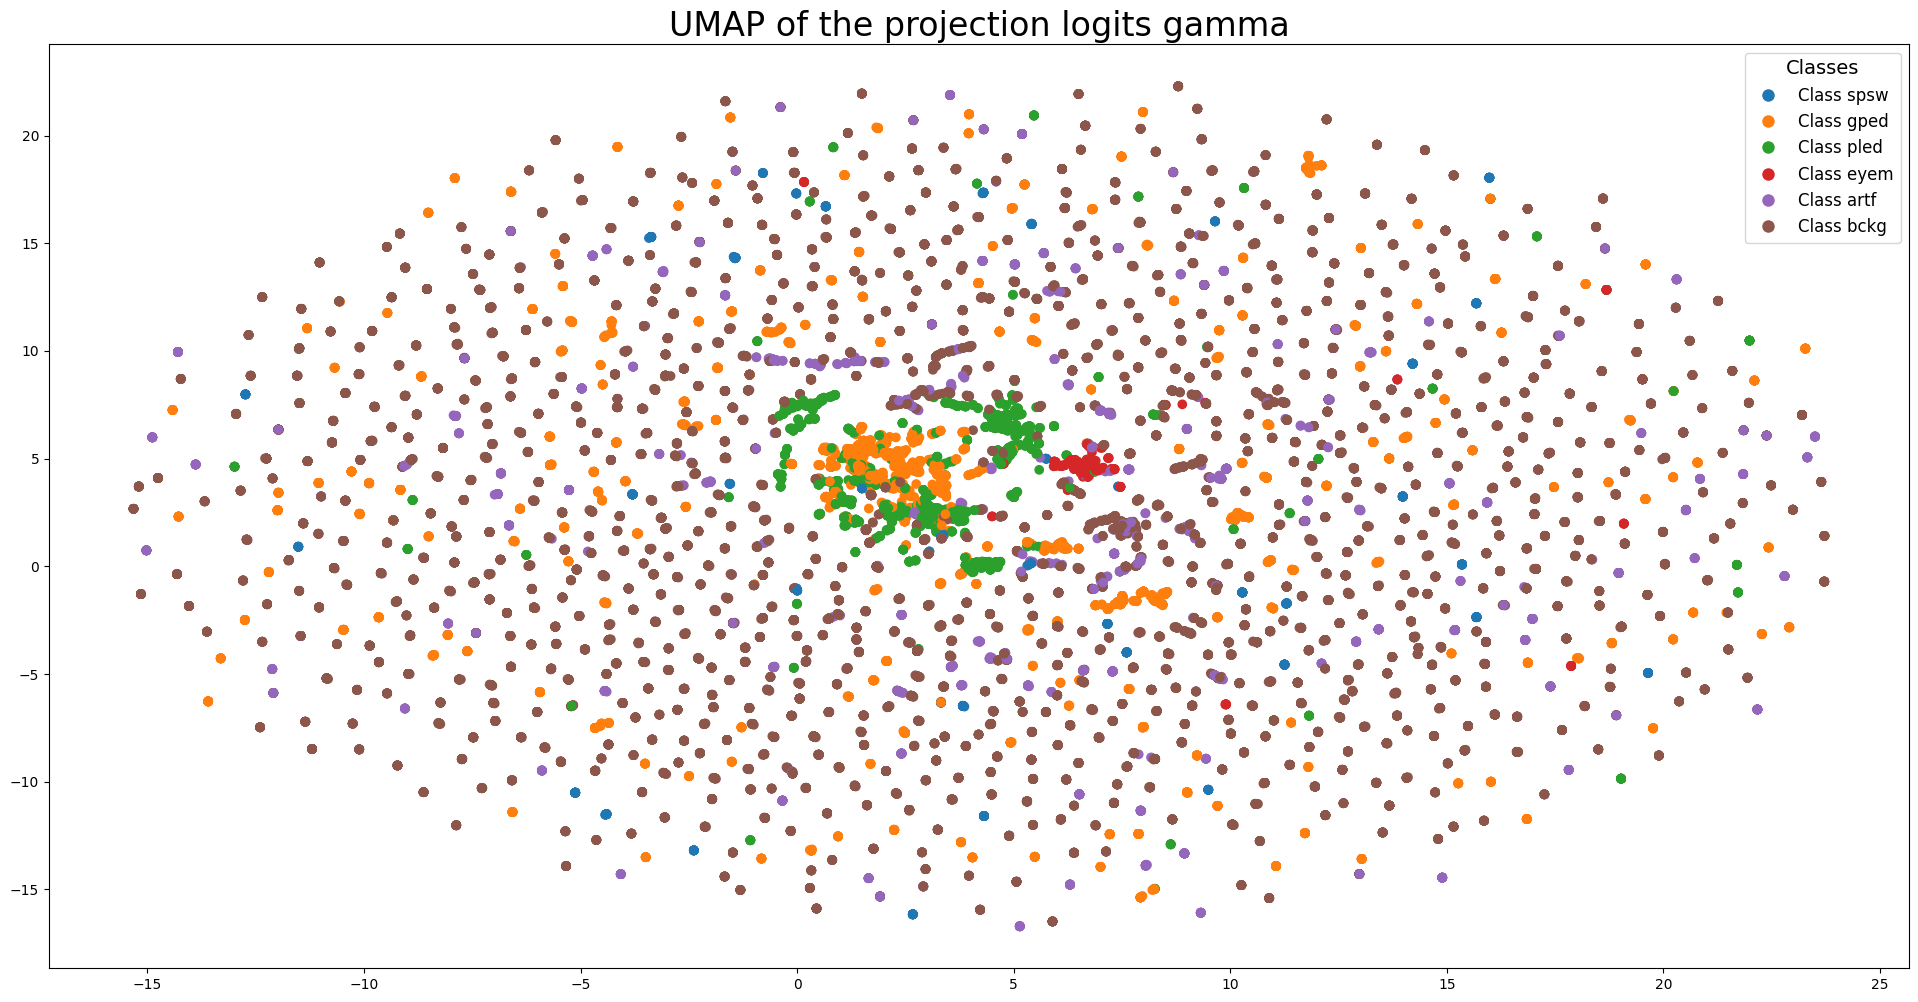

In [40]:
# Define the x-coordinate of the vertical line

fig = plt.figure(figsize=(24, 12))
predictions = reducer2.fit_transform(predictions, job=-1)

# Filter for points of blue color
blue_points = embeddings[output_labels_eval_all == 0]


purple_points = embeddings[output_labels_eval_all == 4]
brown_points = embeddings[output_labels_eval_all == 5]

ax = fig.add_subplot()
ax.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    c=[sns.color_palette()[x] for x in output_labels_eval_all])

'''
ax.scatter(
    blue_points[:, 0],
    blue_points[:, 1],
    c=[sns.color_palette()[0] for x in range(len(blue_points))])

ax.scatter(
    brown_points[:, 0],
    brown_points[:, 1],
    c=[sns.color_palette()[5] for x in range(len(brown_points))])

ax.scatter(
    purple_points[:, 0],
    purple_points[:, 1],
    c=[sns.color_palette()[4] for x in range(len(purple_points))])
'''  
# Create legend handles
unique_labels = np.unique(output_labels_eval_all)
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=sns.color_palette()[label], markersize=10, label=f'Class {label_to_class[label]}')
    for label in unique_labels
]
ax.legend(handles=legend_handles, title="Classes", fontsize=12, title_fontsize=14)
plt.title(f'UMAP of the projection logits {band}', fontsize=24)
plt.show()